In [1]:
import sys
sys.path.append('../src/')
import os
import copy

import numpy as np
import sklearn
from sklearn import metrics
import tensorly as tn
import math
import matlab.engine
import matplotlib.pyplot as plt
import time


import ll1_tools

## Load data and loewnerize (300 node layer)

In [3]:
# targets_path = '../data/L300100_data/targets.npy'
targets_path = '../data/Lenet300100/activations/test/targets.npy'
targets = np.load(targets_path)
print(f"Targets shape: {targets.shape}")

# inputs_path = '../data/L300100_data/99/layers.layer_1.linear.npy'
inputs_path = '../data/Lenet300100/activations/test/99/layers.layer_1.linear.npy'
inputs_raw = np.load(inputs_path)
print(f"Inputs shape: {inputs_raw.shape}")

# outputs_path = '../data/L300100_data/99/layers.layer_1.rat.npy'
outputs_path = '../data/Lenet300100/activations/test/99/layers.layer_1.rat.npy'
outputs_raw = np.load(outputs_path)
print(f"Outputs shape: {outputs_raw.shape}")

# tensorlab_path = '~/ware/matlab_tools/tensorlab'
tensorlab_path = '~/tools/matlab_tools/Tensorlab'

num_sets = 10
tic = time.perf_counter()
lwn_tns_raw, obs, obs_trgts = ll1_tools.split_data(inputs_raw, outputs_raw, targets, tensorlab_path, num_sets)
toc = time.perf_counter()
print(toc-tic)

Targets shape: (9984,)
Inputs shape: (39, 256, 100)
Outputs shape: (39, 256, 100)
62.18029972500517


## remove inf values from lwn_tns: 
Rationale: if numerator of the lowner matrix entry is zero, so would be the numerator, hence replacing inf with zero is justified

In [4]:
lwn_tns = lwn_tns_raw
for t in lwn_tns:
    t[np.isinf(t)] = 0

## perform decompositions for all lwn_tns

In [5]:
eng = matlab.engine.start_matlab()
s = eng.genpath(tensorlab_path)
eng.addpath(s, nargout=0)

num_terms = 250
rat_deg = 9

L = rat_deg * np.ones(num_terms)
mdls = list()
outs = list()

tic = time.perf_counter()
for tns in lwn_tns:
    U, out = eng.ll1(tns, L, nargout=2)
    mdls.append(U)
    outs.append(out)
toc = time.perf_counter()
print(toc-tic)

28422.442380188004


## check model fits

[0.6077066195246581, 0.6012395285846288, 0.6062502829363026, 0.6029574235160581, 0.6075101779720591, 0.6151479310282522, 0.6141171224298079, 0.6166304522587456, 0.6159913903287259, 0.6102598505727063]


Text(0.5, 1.0, '(L,L,1) model Fit Scores')

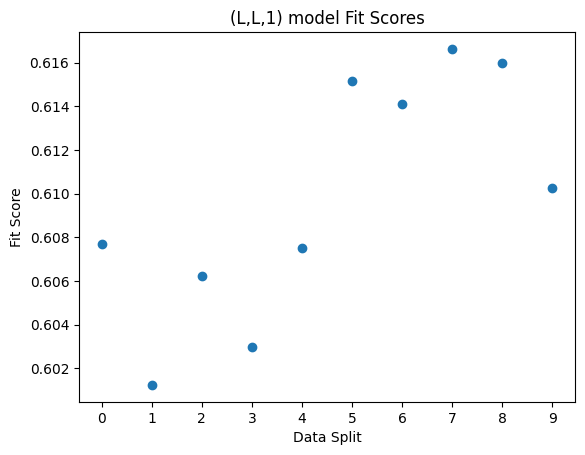

In [6]:
fits = []
for idx, mdl in enumerate(mdls):
    tmp_fit = 1 - eng.frobll1res(lwn_tns[idx], mdl) / eng.frob(lwn_tns[idx])
    fits.append(tmp_fit)
print(fits)
plt.scatter(range(10),fits)
plt.xlabel('Data Split')
plt.ylabel('Fit Score')
plt.xticks(range(10))
plt.title('(L,L,1) model Fit Scores')

## Recover 'Sources' & 'Mixing' matrices for each set

In [7]:
print(f"Number of models: {len(mdls)}")
sources = list()
mixes = list()
for idx, model in enumerate(mdls):
    tmp = ll1_tools.pack_ll1(model)
    mix = tmp[2]
    mixes.append(mix)
    src = ll1_tools.recover_sources(obs[idx], mix)
    sources.append(src)
print(f"Number of Source matrices: {len(sources)}")
print(f"Number of Mixing matrices: {len(mixes)}")

Number of models: 10
Number of Source matrices: 10
Number of Mixing matrices: 10


## Perform SVDs on transposed 'Sources' matrices as well as maximum angle between subspaces
(transpose so the left singular vectors correspond to the sources signal space)

In [8]:
sources_transposed = []
for src in sources:
    sources_transposed.append(src.T)
print(len(sources_transposed))

svds = []
for src in sources_transposed:
    svds.append(np.linalg.svd(src))
num_sets = len(sources)

angles_srcs = np.zeros((num_sets,num_sets))
angles_cols = np.zeros((num_sets,num_sets))
norm_of_diffs = np.zeros((num_sets,num_sets))
# cossims = np.zeros((num_sets,num_sets))
for i in range(num_sets):
    for j in range(num_sets):
        if i != j:
            angles_srcs[i,j] = eng.rad2deg(eng.subspace(sources_transposed[i], sources_transposed[j]))
            angles_cols[i,j] = eng.rad2deg(eng.subspace(svds[i][0], svds[j][0]))
            norm_of_diffs[i,j] = np.linalg.norm(sources_transposed[i] - sources_transposed[j])
            # cossims[i,j] = sklearn.metrics.pairwise.cosine_similarity(sources_transposed[i], sources_transposed[j])
            

10


## SVD analysis

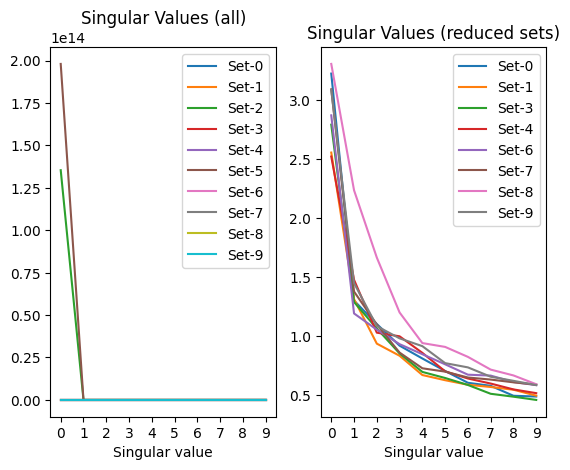

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey='col')

# plot all singular values left side
for i in range(len(svds)):
    ax1.plot(svds[i][1][0:10], label=f"Set-{i}")

ax1.set_title('Singular Values (all)')
ax1.set_xticks(range(10))
ax1.set_xlabel('Singular value')
ax1.legend()

# plot limited set of singular values right side
for i in range(len(svds)):
    if i != 2 and i != 5:
        ax2.plot(svds[i][1][0:10], label=f"Set-{i}")
ax2.set_title('Singular Values (reduced sets)')
ax2.set_xticks(range(10))
ax2.set_xlabel('Singular value')
ax2.legend()

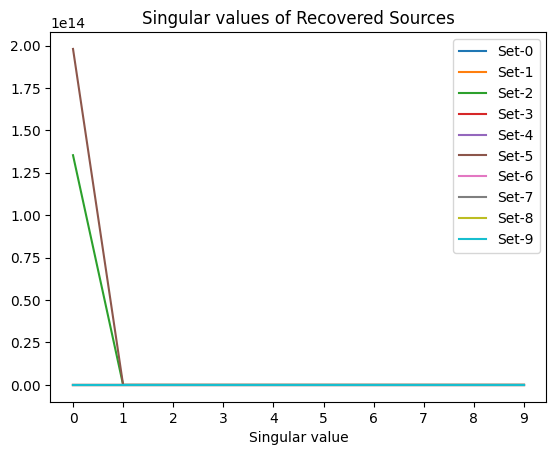

In [9]:
for i in range(len(svds)):
    plt.plot(svds[i][1][0:10], label=f"Set-{i}")
plt.xlabel('Singular value')
plt.xticks(range(len(svds)))
plt.title('Singular values of Recovered Sources')
plt.legend()

### Sets 2 and 5 - investigate target distributions for those sets

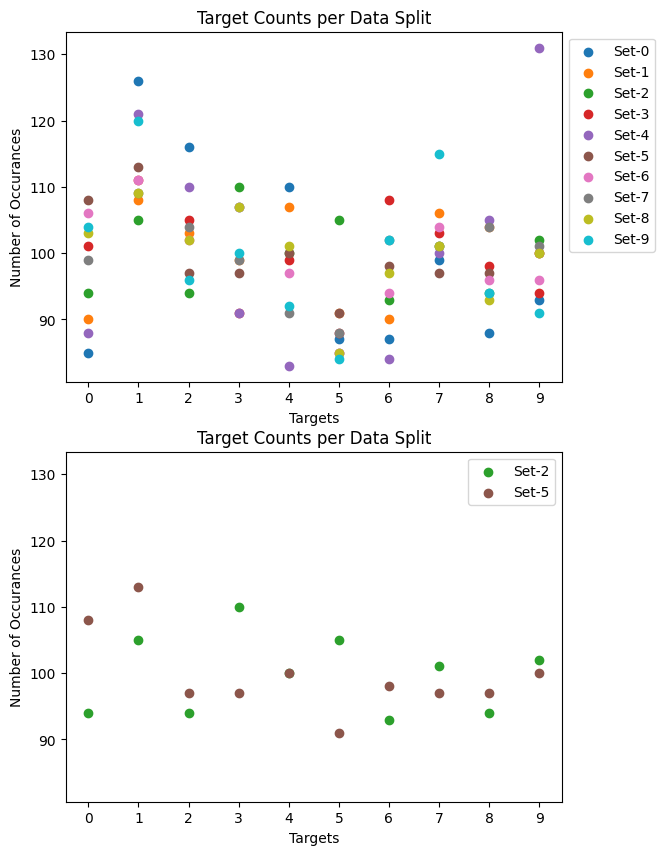

In [62]:
trgts_distros = np.zeros((10,len(obs_trgts)))
for idx, trgts in enumerate(obs_trgts):
    trgts_distros[:,idx] = np.bincount(trgts)

fig, (ax1, ax2) = plt.subplots(2, 1, sharey='col')

for idx in range(10):
    ax1.scatter(range(10), trgts_distros[:,idx], label=f"Set-{idx}")
    if idx == 2:
        ax2.scatter(range(10), trgts_distros[:,idx], label=f"Set-{idx}", c='#2ca02c')
    if idx == 5:
        ax2.scatter(range(10), trgts_distros[:,idx], label=f"Set-{idx}", c='#8c564b')
    

ax1.set_xlabel('Targets')
ax1.set_ylabel('Number of Occurances')
ax1.set_title('Target Counts per Data Split')
ax1.set_xticks(range(10))
ax1.legend(bbox_to_anchor=(1, 1))
ax2.set_xlabel('Targets')
ax2.set_ylabel('Number of Occurances')
ax2.set_title('Target Counts per Data Split')
ax2.set_xticks(range(10))
ax2.legend(bbox_to_anchor=(1, 1))
fig.set_figheight(10)

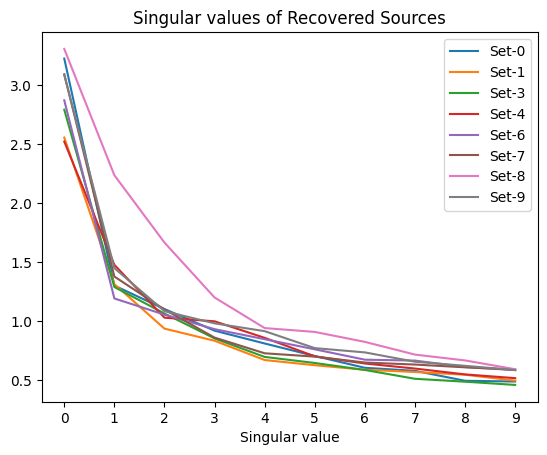

In [13]:
for i in range(len(svds)):
    if i != 2 and i != 5:
        plt.plot(svds[i][1][0:10], label=f"Set-{i}")
plt.xlabel('Singular value')
plt.xticks(range(len(svds)))
plt.title('Singular values of Recovered Sources')
plt.legend()

## Principal Angle Analysis

Text(0.5, 1.0, 'Largest Principal Angle Between Recovered Sources')

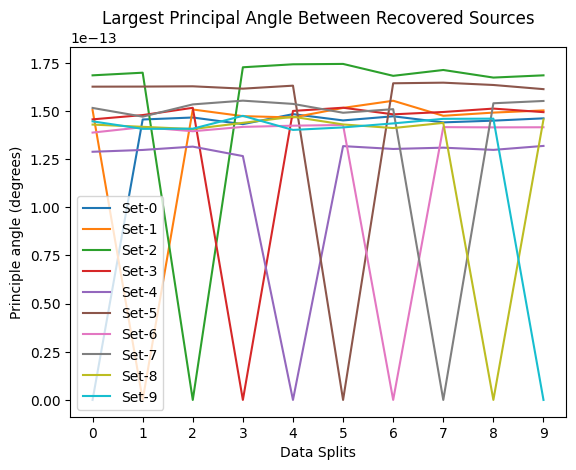

In [10]:
for i in range(angles_cols.shape[0]):
    plt.plot(angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Largest Principal Angle Between Recovered Sources')

Text(0.5, 1.0, 'Principal Angle Between Recovered Sources (all)')

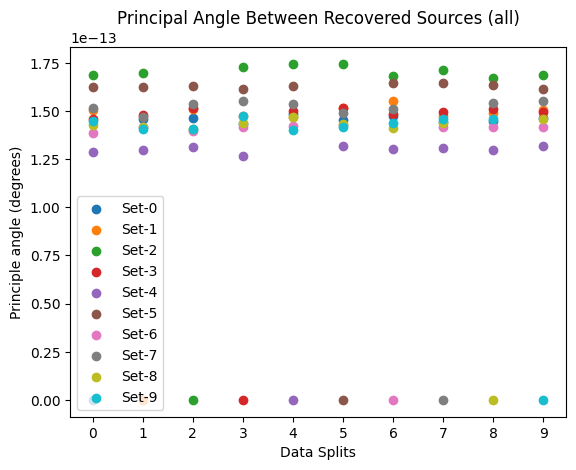

In [29]:
for i in range(angles_cols.shape[0]):
    plt.scatter(range(10),angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Principal Angle Between Recovered Sources (all)')

Text(0.5, 1.0, 'Principal Angle Between Recovered Sources (subset)')

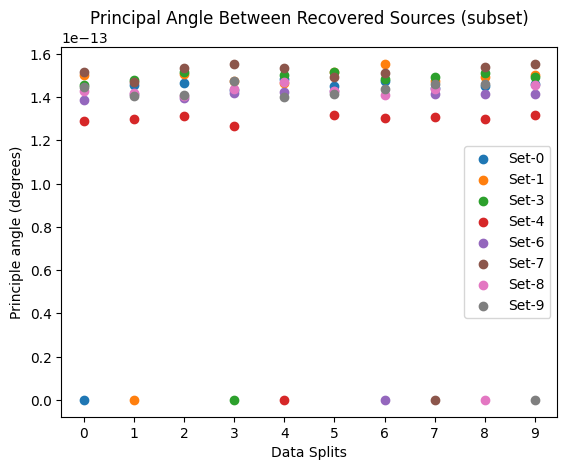

In [30]:
for i in range(angles_cols.shape[0]):
    if i != 2 and i != 5:
        plt.scatter(range(10),angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Principal Angle Between Recovered Sources (subset)')

## Norm of the Difference of Recovered Sources Analysis

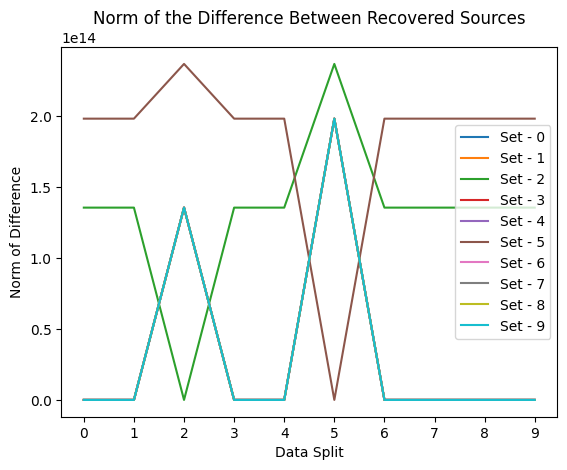

In [14]:
for i in range(norm_of_diffs.shape[0]):
    plt.plot(norm_of_diffs[i,:], label=f"Set - {i}")

plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()

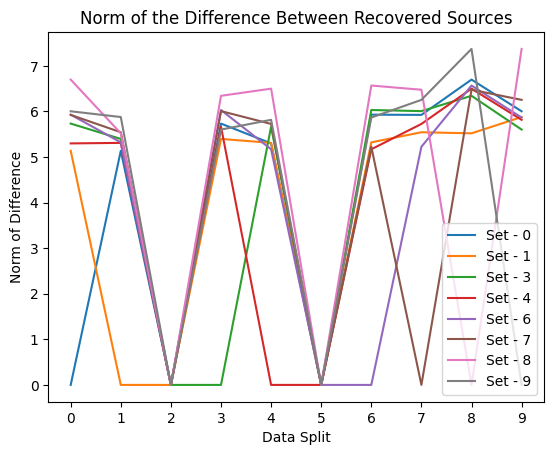

In [19]:
norms_cleaned = norm_of_diffs.copy()

# zero out 2 and 5s
norms_cleaned[2,:] = 0
norms_cleaned[:,2] = 0
norms_cleaned[5,:] = 0
norms_cleaned[:,5] = 0

for i in range(norm_of_diffs.shape[0]):
    if i != 2 and i != 5:
        plt.plot(norms_cleaned[i,:], label=f"Set - {i}")
        
plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()

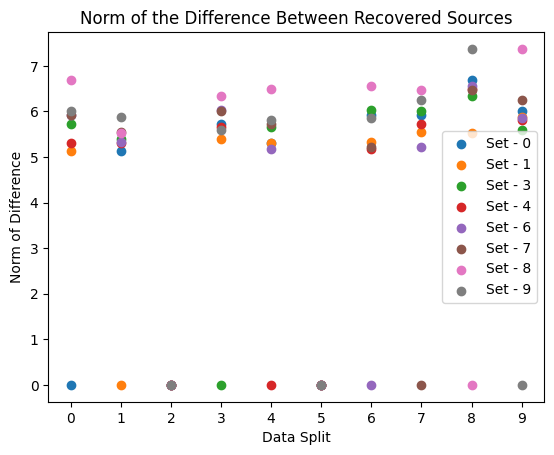

In [21]:
for i in range(norm_of_diffs.shape[0]):
    if i != 2 and i != 5:
        plt.scatter(range(10),norms_cleaned[i,:], label=f"Set - {i}")
        
plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()